### Optimize with 10 kHz $\Omega$ cap

In [1]:
import cu_rsc as cr
cr.setup_tables()
import RSC_sim
import numpy as np
import cupy as cp
import cupyx
import matplotlib.pyplot as plt
from tqdm import tqdm
M_dev = cr.load_m_table_device()        # upload to GPU
res   = cr.resources_from_config(M_dev)

### Sequence optimizing lowest fraction

In [2]:
import numpy as np
seq = np.load("../../pulse_freq_op/ga_runs/OmegaTimeGA_20260228_092608/final_top5/top1_sequence.npy")

Raman pulses: 100%|██████████| 260/260 [00:16<00:00, 15.90it/s]


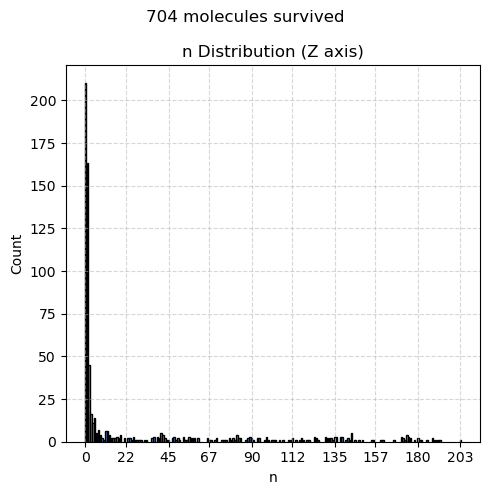

{'survival_rate_mean': array(0.704),
 'survival_rate_sem': array(0.00044871),
 'mot_mean': array([ 1.63636364,  2.99715909, 28.76278409]),
 'mot_sem': array([0.00664794, 0.01004442, 0.06053941]),
 'ground_state_rate_mean': array(0.25994318),
 'ground_state_rate_sem': array(0.00053911),
 'N': array(1000, dtype=int32),
 'Ns_surv': array(704, dtype=int32),
 'B': array(1000, dtype=int32)}

In [3]:
temp = [25e-6, 25e-6, 25e-6]
mol_0 = cr.build_thermal_molecules(1000, temp)
cr.raman_cool_with_pumping(mol_0, seq, res, show_progress=True)
dist = cr.get_n_distribution_gpu(mol_0, max_bins=10, plot=(False, False, True))
result = cr.bootstrap_stats_from_molecules(mol_0)
result

### Compare AOD and SLM molecules

Raman pulses: 100%|██████████| 260/260 [00:14<00:00, 17.42it/s]


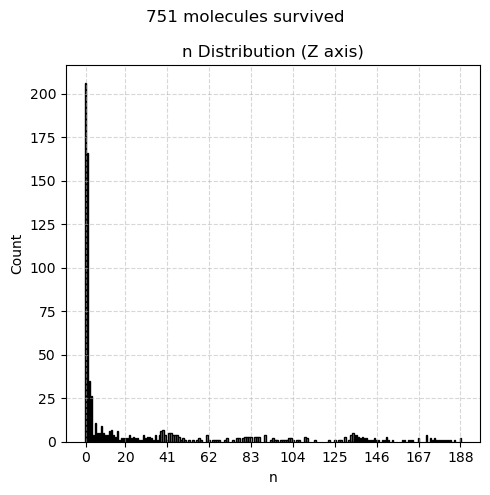

------SLM molecules------
survival rate:  0.751
N_z bar:  29.437
Ground state rate:  0.233


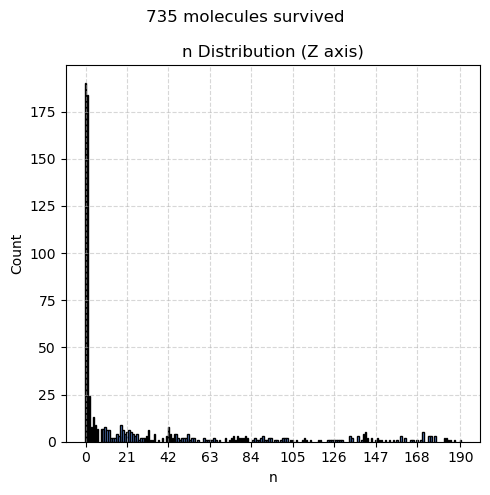

------AOD molecules------
survival rate:  0.735
N_z bar:  29.212
Ground state rate:  0.199


In [4]:
mol_SLM = cr.build_thermal_molecules(1000, temp)
mol_AOD = cr.build_thermal_molecules(
    1000, 
    temp, 
    trap_detuning_mean=-2e3,
    trap_detuning_sigma=0.0,
    carrier_detuning_mean=3e3,
    carrier_detuning_sigma=0.0,)

cr.raman_cool_with_pumping(mol_SLM, seq, res, show_progress=True)
cr.raman_cool_with_pumping(mol_AOD, seq, res, show_progress=True)

dist = cr.get_n_distribution_gpu(mol_SLM, max_bins=10, plot=(False, False, True))
result = cr.bootstrap_stats_from_molecules(mol_SLM)
print("------SLM molecules------")
print("survival rate: ", np.round(result["survival_rate_mean"], 3))
print("N_z bar: ", np.round(result["mot_mean"][2], 3))
print("Ground state rate: ", np.round(result["ground_state_rate_mean"],3))

dist = cr.get_n_distribution_gpu(mol_AOD, max_bins=10, plot=(False, False, True))
result = cr.bootstrap_stats_from_molecules(mol_AOD)
print("------AOD molecules------")
print("survival rate: ", np.round(result["survival_rate_mean"], 3))
print("N_z bar: ", np.round(result["mot_mean"][2], 3))
print("Ground state rate: ", np.round(result["ground_state_rate_mean"],3))


### RST

Raman thermometry: 100%|██████████| 1000/1000 [00:06<00:00, 153.04it/s]


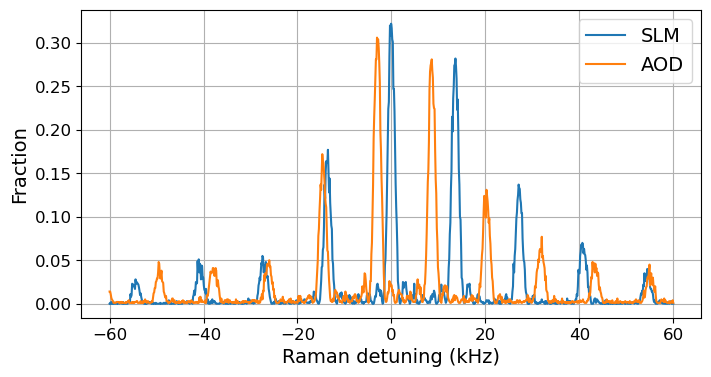

In [5]:
zt_freqs = cp.linspace(-60e3, 60e3, 1000)
zt_rabi = 1.01e3
zt_pulse = 500e-6

plt.figure(figsize=(8,4))
frequencys, polarizations_opt = cr.raman_sideband_thermometry(
    molecules_dev=mol_SLM,
    axis=2,
    frequencys=zt_freqs,
    rabi_freq=zt_rabi,
    pulse_time=zt_pulse,
    res=res,
    k_max=2
)

plt.plot(cp.asnumpy(frequencys*1e-3), cp.asnumpy(polarizations_opt)/1000, label='SLM')

frequencys, polarizations_opt = cr.raman_sideband_thermometry(
    molecules_dev=mol_AOD,
    axis=2,
    frequencys=zt_freqs,
    rabi_freq=zt_rabi,
    pulse_time=zt_pulse,
    res=res,
    k_max=2
)

plt.plot(cp.asnumpy(frequencys*1e-3), cp.asnumpy(polarizations_opt)/1000, label='AOD')
plt.xlabel("Raman detuning (kHz)", fontsize=14)
plt.ylabel("Fraction", fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=14)
plt.grid()

#### This is not better than before. Use 0219 optimization 

In [4]:
best_seq = np.load("../pulse_detuning/top1_sequence.npy")

In [5]:
caps = np.linspace(10e3, 30e3, 9)

# Storage arrays
slm_survival = []
slm_nz_bar = []
slm_ground = []

aod_survival = []
aod_nz_bar = []
aod_ground = []

for cap in tqdm(caps):
    # Copy sequence so original is untouched
    cap_seq = best_seq.copy()

    # Apply cap to omega (column index 2)
    for seq in cap_seq:
        if seq[2] > cap:
            seq[2] = cap

    temp = [25e-6, 25e-6, 25e-6]

    mol_SLM = cr.build_thermal_molecules(1000, temp)

    mol_AOD = cr.build_thermal_molecules(
        1000,
        temp,
        trap_detuning_mean=-2e3,
        trap_detuning_sigma=0.0,
        carrier_detuning_mean=3e3,
        carrier_detuning_sigma=0.0,
    )

    cr.raman_cool_with_pumping(mol_SLM, cap_seq, res, show_progress=False)
    cr.raman_cool_with_pumping(mol_AOD, cap_seq, res, show_progress=False)

    # ---- SLM ----
    result_slm = cr.bootstrap_stats_from_molecules(mol_SLM)

    slm_survival.append(float(result_slm["survival_rate_mean"]))
    slm_nz_bar.append(float(result_slm["mot_mean"][2]))
    slm_ground.append(float(result_slm["ground_state_rate_mean"]))

    # ---- AOD ----
    result_aod = cr.bootstrap_stats_from_molecules(mol_AOD)

    aod_survival.append(float(result_aod["survival_rate_mean"]))
    aod_nz_bar.append(float(result_aod["mot_mean"][2]))
    aod_ground.append(float(result_aod["ground_state_rate_mean"]))

# Convert to arrays
slm_survival = np.array(slm_survival)
slm_nz_bar = np.array(slm_nz_bar)
slm_ground = np.array(slm_ground)

aod_survival = np.array(aod_survival)
aod_nz_bar = np.array(aod_nz_bar)
aod_ground = np.array(aod_ground)


100%|██████████| 9/9 [04:57<00:00, 33.09s/it]


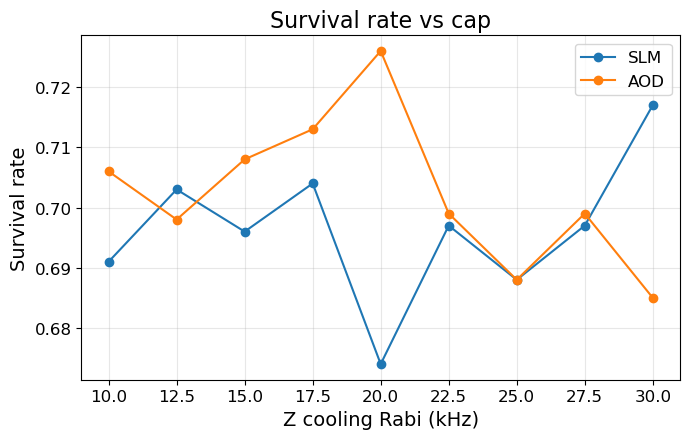

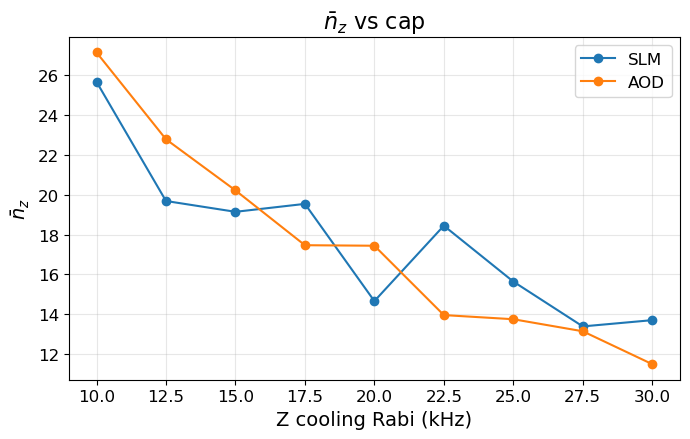

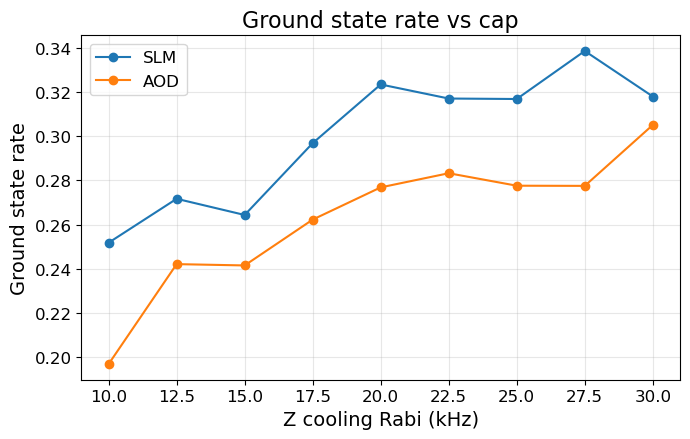

In [7]:
import matplotlib.pyplot as plt

# caps, slm_survival, slm_nz_bar, slm_ground, aod_survival, aod_nz_bar, aod_ground assumed defined

caps_khz = caps / 1e3  # nicer x-axis

# -------------------------
# 1) Survival rate vs cap
# -------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(caps_khz, slm_survival, "o-", label="SLM")
ax.plot(caps_khz, aod_survival, "o-", label="AOD")
ax.set_xlabel("Z cooling Rabi (kHz)", fontsize=14)
ax.set_ylabel("Survival rate", fontsize=14)
ax.set_title("Survival rate vs cap", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# -------------------------
# 2) N̄z vs cap
# -------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(caps_khz, slm_nz_bar, "o-", label="SLM")
ax.plot(caps_khz, aod_nz_bar, "o-", label="AOD")
ax.set_xlabel("Z cooling Rabi (kHz)", fontsize=14)
ax.set_ylabel(r"$\bar{n}_z$", fontsize=14)
ax.set_title(r"$\bar{n}_z$ vs cap", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# -------------------------
# 3) Ground state rate vs cap
# -------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(caps_khz, slm_ground, "o-", label="SLM")
ax.plot(caps_khz, aod_ground, "o-", label="AOD")
ax.set_xlabel("Z cooling Rabi (kHz)", fontsize=14)
ax.set_ylabel("Ground state rate", fontsize=14)
ax.set_title("Ground state rate vs cap", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


### Check sequence robustness if we cap at 20 kHz

#### detuning

In [8]:
dets = np.linspace(-5e3, 5e3, 9)
cap = 20e3
# Storage arrays
slm_survival = []
slm_nz_bar = []
slm_ground = []

aod_survival = []
aod_nz_bar = []
aod_ground = []

for det in tqdm(dets):
    # Copy sequence so original is untouched
    cap_seq = best_seq.copy()

    # Apply cap to omega (column index 2)
    for seq in cap_seq:
        if seq[2] > cap:
            seq[2] = cap
        seq[4] = seq[4] + det

    temp = [25e-6, 25e-6, 25e-6]

    mol_SLM = cr.build_thermal_molecules(1000, temp)

    mol_AOD = cr.build_thermal_molecules(
        1000,
        temp,
        trap_detuning_mean=-2e3,
        trap_detuning_sigma=0.0,
        carrier_detuning_mean=3e3,
        carrier_detuning_sigma=0.0,
    )

    cr.raman_cool_with_pumping(mol_SLM, cap_seq, res, show_progress=False)
    cr.raman_cool_with_pumping(mol_AOD, cap_seq, res, show_progress=False)

    # ---- SLM ----
    result_slm = cr.bootstrap_stats_from_molecules(mol_SLM)

    slm_survival.append(float(result_slm["survival_rate_mean"]))
    slm_nz_bar.append(float(result_slm["mot_mean"][2]))
    slm_ground.append(float(result_slm["ground_state_rate_mean"]))

    # ---- AOD ----
    result_aod = cr.bootstrap_stats_from_molecules(mol_AOD)

    aod_survival.append(float(result_aod["survival_rate_mean"]))
    aod_nz_bar.append(float(result_aod["mot_mean"][2]))
    aod_ground.append(float(result_aod["ground_state_rate_mean"]))

# Convert to arrays
slm_survival = np.array(slm_survival)
slm_nz_bar = np.array(slm_nz_bar)
slm_ground = np.array(slm_ground)

aod_survival = np.array(aod_survival)
aod_nz_bar = np.array(aod_nz_bar)
aod_ground = np.array(aod_ground)


100%|██████████| 9/9 [04:40<00:00, 31.21s/it]


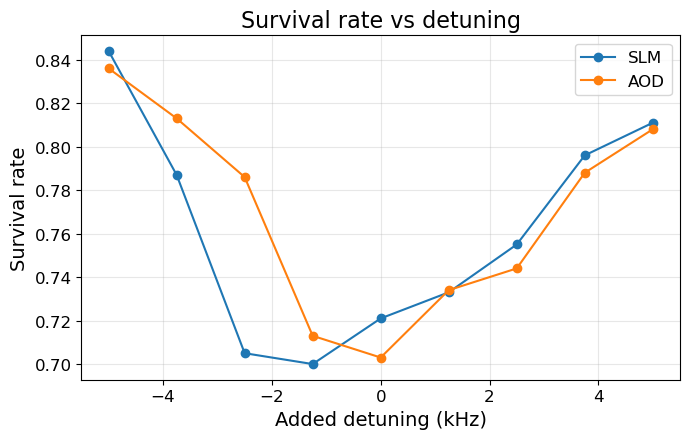

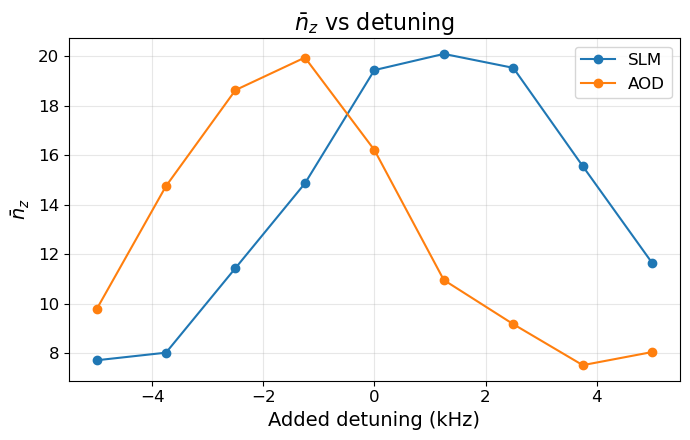

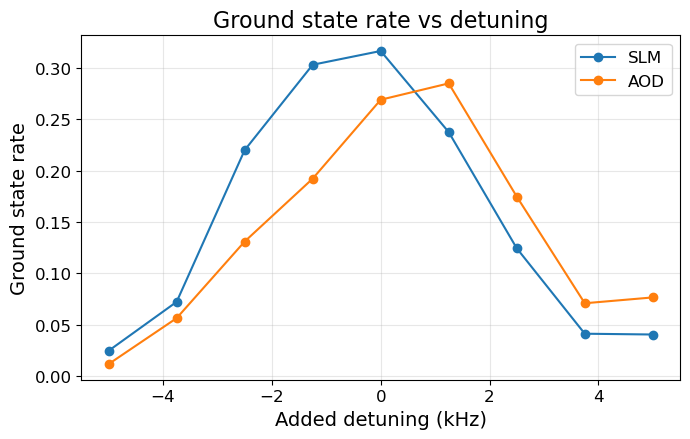

In [9]:
import matplotlib.pyplot as plt

dets_khz = dets / 1e3  # convert to kHz for plotting

# -------------------------
# 1) Survival rate vs detuning
# -------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(dets_khz, slm_survival, "o-", label="SLM")
ax.plot(dets_khz, aod_survival, "o-", label="AOD")
ax.set_xlabel("Added detuning (kHz)", fontsize=14)
ax.set_ylabel("Survival rate", fontsize=14)
ax.set_title("Survival rate vs detuning", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# -------------------------
# 2) N̄z vs detuning
# -------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(dets_khz, slm_nz_bar, "o-", label="SLM")
ax.plot(dets_khz, aod_nz_bar, "o-", label="AOD")
ax.set_xlabel("Added detuning (kHz)", fontsize=14)
ax.set_ylabel(r"$\bar{n}_z$", fontsize=14)
ax.set_title(r"$\bar{n}_z$ vs detuning", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# -------------------------
# 3) Ground state rate vs detuning
# -------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(dets_khz, slm_ground, "o-", label="SLM")
ax.plot(dets_khz, aod_ground, "o-", label="AOD")
ax.set_xlabel("Added detuning (kHz)", fontsize=14)
ax.set_ylabel("Ground state rate", fontsize=14)
ax.set_title("Ground state rate vs detuning", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


#### 2D scan

In [10]:
from tqdm import tqdm
import numpy as np

# Scan ranges
caps = np.linspace(10e3, 30e3, 9)
dets = np.linspace(-5e3, 5e3, 9)

Nc = len(caps)
Nd = len(dets)

# -------------------------
# Allocate 2D storage arrays
# shape = (N_caps, N_dets)
# -------------------------
slm_survival = np.zeros((Nc, Nd))
slm_nz_bar   = np.zeros((Nc, Nd))
slm_ground   = np.zeros((Nc, Nd))

aod_survival = np.zeros((Nc, Nd))
aod_nz_bar   = np.zeros((Nc, Nd))
aod_ground   = np.zeros((Nc, Nd))

temp = [25e-6, 25e-6, 25e-6]

# -------------------------
# 2D scan
# -------------------------
for i, cap in enumerate(tqdm(caps)):
    for j, det in enumerate(dets):

        # Copy sequence so original is untouched
        cap_seq = best_seq.copy()

        # Apply cap and detuning shift
        for seq in cap_seq:
            if seq[2] > cap:
                seq[2] = cap
            seq[4] = seq[4] + det

        # Build molecules
        mol_SLM = cr.build_thermal_molecules(1000, temp)

        mol_AOD = cr.build_thermal_molecules(
            1000,
            temp,
            trap_detuning_mean=-2e3,
            trap_detuning_sigma=0.0,
            carrier_detuning_mean=3e3,
            carrier_detuning_sigma=0.0,
        )

        # Run cooling
        cr.raman_cool_with_pumping(mol_SLM, cap_seq, res, show_progress=False)
        cr.raman_cool_with_pumping(mol_AOD, cap_seq, res, show_progress=False)

        # ---- SLM ----
        result_slm = cr.bootstrap_stats_from_molecules(mol_SLM)

        slm_survival[i, j] = float(result_slm["survival_rate_mean"])
        slm_nz_bar[i, j]   = float(result_slm["mot_mean"][2])
        slm_ground[i, j]   = float(result_slm["ground_state_rate_mean"])

        # ---- AOD ----
        result_aod = cr.bootstrap_stats_from_molecules(mol_AOD)

        aod_survival[i, j] = float(result_aod["survival_rate_mean"])
        aod_nz_bar[i, j]   = float(result_aod["mot_mean"][2])
        aod_ground[i, j]   = float(result_aod["ground_state_rate_mean"])


100%|██████████| 9/9 [41:56<00:00, 279.66s/it]


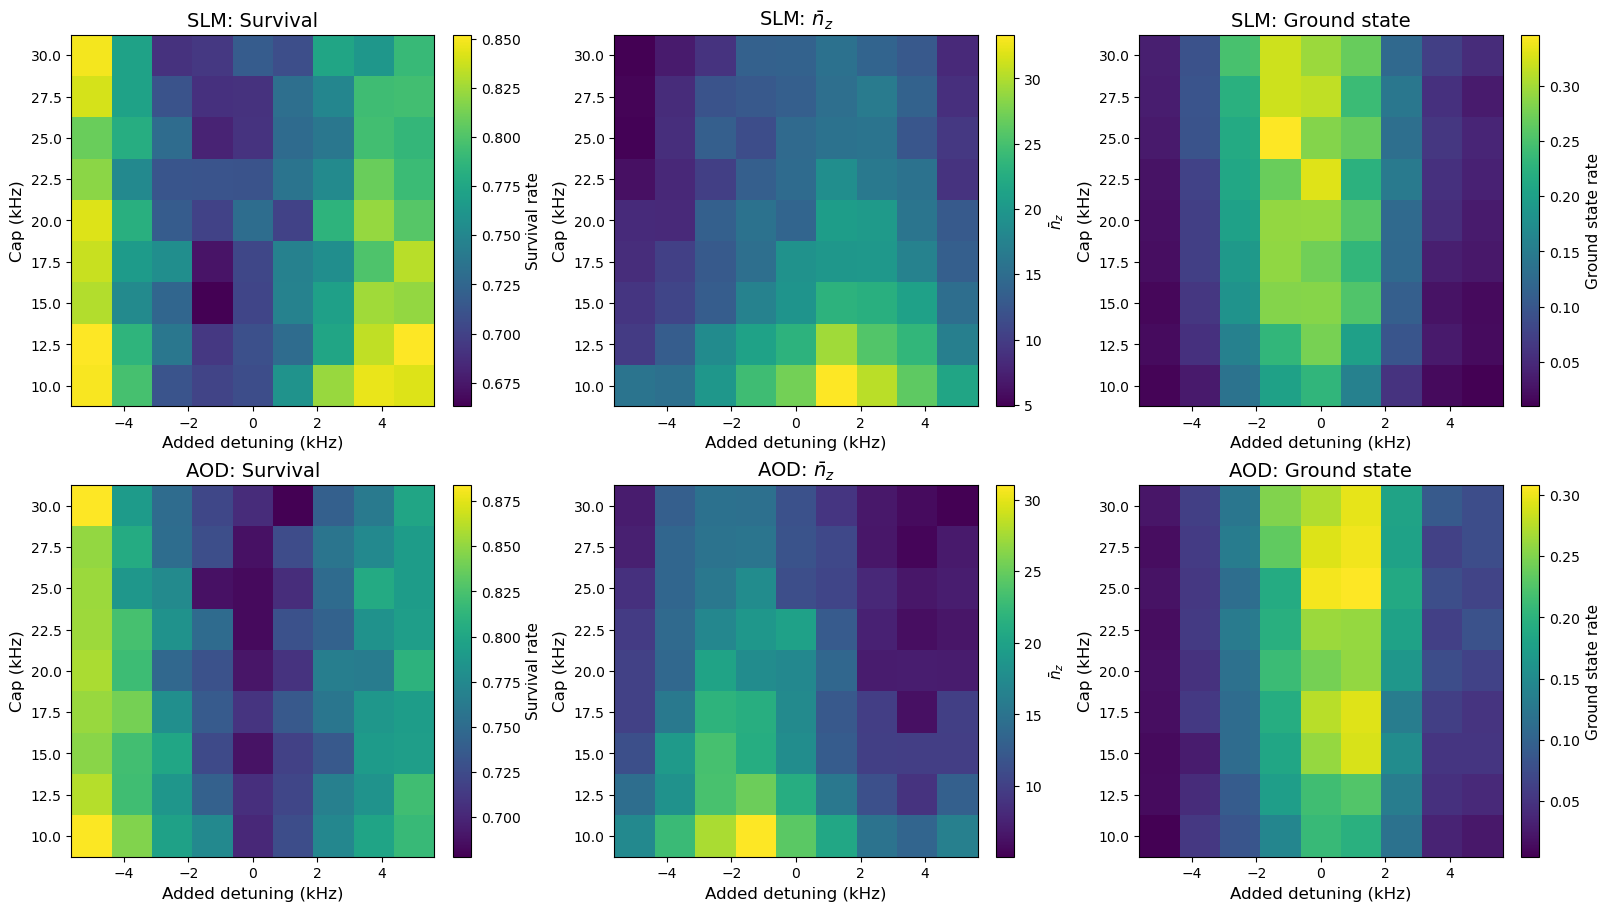

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes:
# caps, dets (Hz)
# slm_survival, slm_nz_bar, slm_ground  shape (Nc, Nd)
# aod_survival, aod_nz_bar, aod_ground  shape (Nc, Nd)

def _edges_from_centers(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    dx = np.diff(x)
    if len(dx) == 0:
        return np.array([x[0] - 0.5, x[0] + 0.5], dtype=float)
    if not np.allclose(dx, dx[0]):
        edges = np.empty(len(x) + 1, dtype=float)
        edges[1:-1] = 0.5 * (x[:-1] + x[1:])
        edges[0] = x[0] - 0.5 * (x[1] - x[0])
        edges[-1] = x[-1] + 0.5 * (x[-1] - x[-2])
        return edges
    d = dx[0]
    return np.concatenate(([x[0] - d / 2], x + d / 2))

caps_khz = caps / 1e3
dets_khz = dets / 1e3

cap_edges = _edges_from_centers(caps_khz)
det_edges = _edges_from_centers(dets_khz)
X, Y = np.meshgrid(det_edges, cap_edges)  # edges grid for pcolormesh

def heat(ax, Z, title, cbar_label):
    im = ax.pcolormesh(X, Y, Z, shading="flat")
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Added detuning (kHz)", fontsize=12)
    ax.set_ylabel("Cap (kHz)", fontsize=12)
    ax.tick_params(axis="both", labelsize=10)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label, fontsize=11)
    cbar.ax.tick_params(labelsize=10)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

# Row 1: SLM
heat(axes[0, 0], slm_survival, "SLM: Survival", "Survival rate")
heat(axes[0, 1], slm_nz_bar,   r"SLM: $\bar{n}_z$", r"$\bar{n}_z$")
heat(axes[0, 2], slm_ground,   "SLM: Ground state", "Ground state rate")

# Row 2: AOD
heat(axes[1, 0], aod_survival, "AOD: Survival", "Survival rate")
heat(axes[1, 1], aod_nz_bar,   r"AOD: $\bar{n}_z$", r"$\bar{n}_z$")
heat(axes[1, 2], aod_ground,   "AOD: Ground state", "Ground state rate")

plt.show()


#### Count nz <= 1

In [14]:
from typing import Tuple

def score_molecules(
    mol: cp.ndarray,
    *,
    max_nz: int = 1,
) -> Tuple[int, float, float]:
    if mol.ndim != 2 or mol.shape[1] < 6:
        raise ValueError("mol must be shape (N,6)")

    n_x = mol[:, 0]
    n_y = mol[:, 1]
    n_z = mol[:, 2]
    mN  = mol[:, 3]
    spin = mol[:, 4]
    is_lost = mol[:, 5]

    N = int(mol.shape[0])

    survived = (mN == 1) & (spin == 0) & (is_lost == 0)
    surv_count = int(cp.count_nonzero(survived).get())

    meet_n_condition = (n_x == 0) & (n_y == 0) & (n_z <= int(max_nz))
    good_mask = survived & meet_n_condition

    score_count = int(cp.count_nonzero(good_mask).get())
    good_fraction = float(surv_count / N) if N > 0 else 0.0

    if surv_count > 0:
        nz_sum = cp.sum(n_z[survived]).astype(cp.float64)
        nz_bar = float((nz_sum / float(surv_count)).get())
    else:
        nz_bar = float("nan")

    return score_count, good_fraction, nz_bar

In [15]:
from tqdm import tqdm
import numpy as np
import cupy as cp

# Scan ranges
caps = np.linspace(10e3, 30e3, 9)
dets = np.linspace(-5e3, 5e3, 9)

Nc = len(caps)
Nd = len(dets)

# -------------------------
# Allocate 2D storage arrays
# shape = (N_caps, N_dets)
# -------------------------
slm_survival = np.zeros((Nc, Nd))
slm_nz_bar   = np.zeros((Nc, Nd))
slm_score    = np.zeros((Nc, Nd), dtype=int)   # count of (nx,ny,nz)<=(0,0,1) among survived

aod_survival = np.zeros((Nc, Nd))
aod_nz_bar   = np.zeros((Nc, Nd))
aod_score    = np.zeros((Nc, Nd), dtype=int)

temp = [25e-6, 25e-6, 25e-6]

# -------------------------
# 2D scan
# -------------------------
for i, cap in enumerate(tqdm(caps)):
    for j, det in enumerate(dets):

        # Copy sequence so original is untouched
        cap_seq = best_seq.copy()

        # Apply cap and detuning shift
        for seq in cap_seq:
            if seq[2] > cap:
                seq[2] = cap
            seq[4] = seq[4] + det

        # Build molecules
        mol_SLM = cr.build_thermal_molecules(1000, temp)

        mol_AOD = cr.build_thermal_molecules(
            1000,
            temp,
            trap_detuning_mean=-2e3,
            trap_detuning_sigma=0.0,
            carrier_detuning_mean=3e3,
            carrier_detuning_sigma=0.0,
        )

        # Run cooling
        cr.raman_cool_with_pumping(mol_SLM, cap_seq, res, show_progress=False)
        cr.raman_cool_with_pumping(mol_AOD, cap_seq, res, show_progress=False)

        # ---- SLM ----
        score_count, good_fraction, nz_bar = score_molecules(mol_SLM, max_nz=1)
        slm_score[i, j]    = int(score_count)      # number of good molecules
        slm_survival[i, j] = float(good_fraction)  # survival fraction (as defined in score_molecules)
        slm_nz_bar[i, j]   = float(nz_bar)         # mean nz among survived

        # ---- AOD ----
        score_count, good_fraction, nz_bar = score_molecules(mol_AOD, max_nz=1)
        aod_score[i, j]    = int(score_count)
        aod_survival[i, j] = float(good_fraction)
        aod_nz_bar[i, j]   = float(nz_bar)


100%|██████████| 9/9 [39:36<00:00, 264.10s/it]


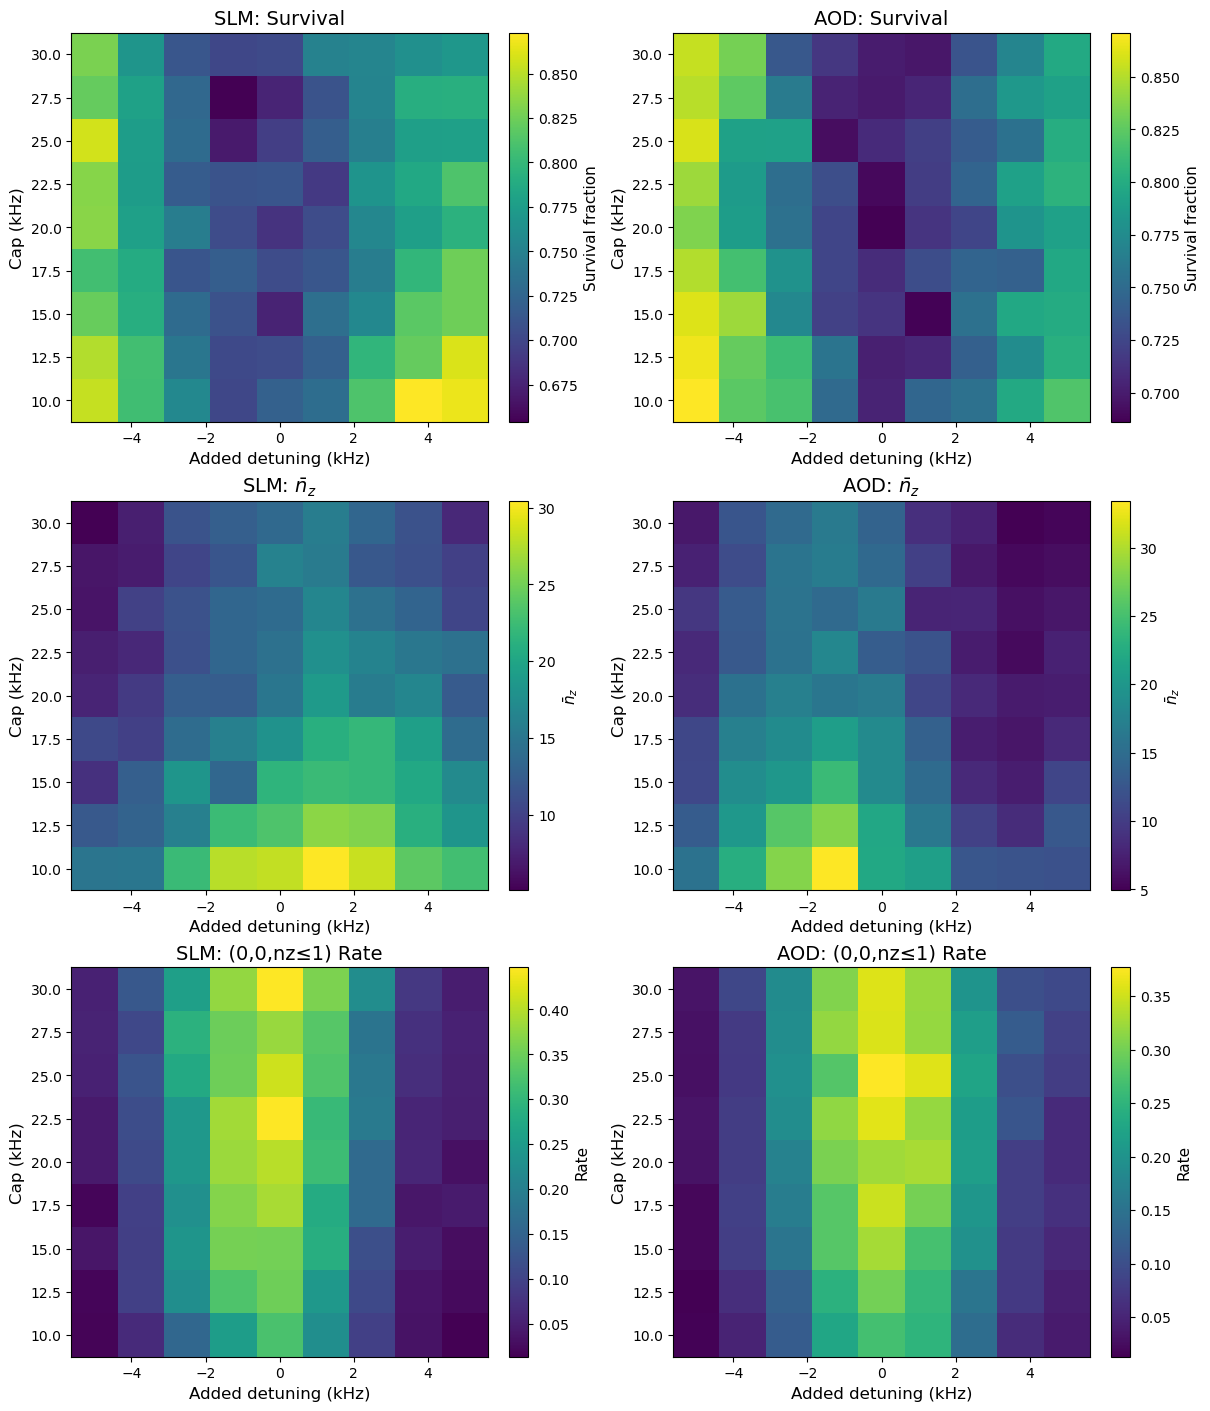

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes:
# caps, dets (Hz)
# slm_survival, slm_nz_bar, slm_score
# aod_survival, aod_nz_bar, aod_score

def _edges_from_centers(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    dx = np.diff(x)
    if len(dx) == 0:
        return np.array([x[0] - 0.5, x[0] + 0.5], dtype=float)
    if not np.allclose(dx, dx[0]):
        edges = np.empty(len(x) + 1, dtype=float)
        edges[1:-1] = 0.5 * (x[:-1] + x[1:])
        edges[0] = x[0] - 0.5 * (x[1] - x[0])
        edges[-1] = x[-1] + 0.5 * (x[-1] - x[-2])
        return edges
    d = dx[0]
    return np.concatenate(([x[0] - d / 2], x + d / 2))

caps_khz = caps / 1e3
dets_khz = dets / 1e3

cap_edges = _edges_from_centers(caps_khz)
det_edges = _edges_from_centers(dets_khz)
X, Y = np.meshgrid(det_edges, cap_edges)

def heat(ax, Z, title, cbar_label):
    im = ax.pcolormesh(X, Y, Z, shading="flat")
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Added detuning (kHz)", fontsize=12)
    ax.set_ylabel("Cap (kHz)", fontsize=12)
    ax.tick_params(axis="both", labelsize=10)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label, fontsize=11)
    cbar.ax.tick_params(labelsize=10)

# 3 rows × 2 columns (TRANSPOSED layout)
fig, axes = plt.subplots(3, 2, figsize=(12, 14), constrained_layout=True)

# Row 1: Survival
heat(axes[0, 0], slm_survival, "SLM: Survival", "Survival fraction")
heat(axes[0, 1], aod_survival, "AOD: Survival", "Survival fraction")

# Row 2: n̄z
heat(axes[1, 0], slm_nz_bar, r"SLM: $\bar{n}_z$", r"$\bar{n}_z$")
heat(axes[1, 1], aod_nz_bar, r"AOD: $\bar{n}_z$", r"$\bar{n}_z$")

# Row 3: Score count
heat(axes[2, 0], slm_score/1000, "SLM: (0,0,nz≤1) Rate", "Rate")
heat(axes[2, 1], aod_score/1000, "AOD: (0,0,nz≤1) Rate", "Rate")

plt.show()
